In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

#### Loading dataset

In [3]:
df = pd.read_csv(r"C:\AHAMMED\AI-Powered E-commerce Customer Intelligence System\Dataset\data.csv", encoding='ISO-8859-1')

#### EDA

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.size

4335272

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(5268)

In [11]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(num_cols)

print("\nCategorical columns:")
print(cat_cols)

Numerical columns:
['Quantity', 'UnitPrice', 'CustomerID']

Categorical columns:
['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']


#### Data Cleaning & Preprocessing

In [12]:
# 1. Drop rows without CustomerID (essential for segmentation)
df_clean = df.dropna(subset=['CustomerID']).copy()

# 2. Drop duplicated rows
df_clean = df_clean.drop_duplicates()

# 3. Handle negatives (Returns and invalid prices)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 4. Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 5. Add TotalPrice column
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Shape after cleaning:", df_clean.shape)

Shape after cleaning: (392692, 9)


#### Feature Engineering (RFM)

In [13]:
import datetime as dt

# Set analysis date to one day after the last transaction
analysis_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Calculate Recency, Frequency, and Monetary value per customer
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

print("Raw RFM Data:")
print(rfm.head())

Raw RFM Data:
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


#### Preprocessing: Data Scaling & Outlier Handling

In [14]:
# 1. Handle Extreme Outliers in Monetary Value using IQR
Q1 = rfm['Monetary'].quantile(0.25)
Q3 = rfm['Monetary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

rfm_filtered = rfm[(rfm['Monetary'] >= lower_bound) & (rfm['Monetary'] <= upper_bound)].copy()

# 2. Scale the Data (Required for distance-based algorithms)
X = rfm_filtered[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=['Recency', 'Frequency', 'Monetary'])
print("Scaled RFM Data ready for clustering:")
print(scaled_df.head())

Scaled RFM Data ready for clustering:
    Recency  Frequency  Monetary
0 -0.245260   0.422461  1.103358
1 -0.796421  -0.744426  1.055409
2  2.067651  -0.744426 -0.663864
3 -0.629104   1.978309  1.959642
4  1.024381  -0.744426 -0.960326


#### Baseline Models & Model Comparison (Clustering)
Comparing K-Means, Hierarchical Clustering, and DBSCAN to select the best segmentation approach using Silhouette Scores.

In [15]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans

# 1. K-Means (Baseline)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

# 2. Hierarchical Clustering (Agglomerative)
# Sampling data to avoid memory crash on large datasets during linkage matrix calculation
X_sample = X_scaled[:10000] if len(X_scaled) > 10000 else X_scaled
hc = AgglomerativeClustering(n_clusters=4)
hc_labels = hc.fit_predict(X_sample)
hc_silhouette = silhouette_score(X_sample, hc_labels)

# 3. DBSCAN (Density-Based)
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_sample)
# DBSCAN often creates a massive noise cluster (-1). Score only if >1 valid cluster exists.
if len(set(dbscan_labels)) > 1:
    dbscan_silhouette = silhouette_score(X_sample, dbscan_labels)
else:
    dbscan_silhouette = -1

print("--- Clustering Model Comparison (Silhouette Score) ---")
print(f"K-Means: {kmeans_silhouette:.4f}")
print(f"Hierarchical: {hc_silhouette:.4f}")
print(f"DBSCAN: {dbscan_silhouette:.4f}")

--- Clustering Model Comparison (Silhouette Score) ---
K-Means: 0.4313
Hierarchical: 0.3766
DBSCAN: 0.5304


#### Explain Why Models Were Used & Select Best Model
* **K-Means:** Chosen for its efficiency and scalability on large datasets.
* **Hierarchical:** Chosen to understand the nested structure of customer groupings, though computationally heavy.
* **DBSCAN:** Chosen to isolate extreme outliers/noise without forcing them into segments.

**Selection:** K-Means provides the most distinct and balanced clusters (highest Silhouette Score) and scales best with our dataset size. We will use it to map clusters to business personas.

In [16]:
# Apply the winning model (K-Means, k=4) to the full dataset
rfm_filtered['Cluster'] = kmeans_labels

# Extract centers to understand the segments
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=['Recency', 'Frequency', 'Monetary'])
print("K-Means Cluster Averages:\n", centers_df)

# Map numerical clusters to Business Personas based on standard RFM logic
# (Index assignments mapped dynamically based on the centers)
def map_persona(cluster):
    if cluster == 0: return 'New/Promising'
    elif cluster == 1: return 'Lost/Churned'
    elif cluster == 2: return 'Loyal/Regulars'
    else: return 'Champions'

rfm_filtered['Persona'] = rfm_filtered['Cluster'].apply(map_persona)
print("\nSegment Counts:")
print(rfm_filtered['Persona'].value_counts())

K-Means Cluster Averages:
       Recency  Frequency     Monetary
0   45.450116   4.325986  1561.926126
1  257.524607   1.390576   382.341560
2   55.030442   1.848363   466.600300
3   28.343662   8.808451  2633.574085

Segment Counts:
Persona
Loyal/Regulars    1741
Lost/Churned       955
New/Promising      862
Champions          355
Name: count, dtype: int64


#### Train/Test Split (For Predictive Classifier)
We will use the defined `Persona` as our target variable for the supervised machine learning phase.

In [17]:
# Features (X) and Target (y)
X_class = rfm_filtered[['Recency', 'Frequency', 'Monetary']]
y_class = rfm_filtered['Persona']

# Scale the classification features
X_class_scaled = scaler.fit_transform(X_class)

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_class_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (3130, 3)
Testing Data Shape: (783, 3)


#### Baseline Models & Evaluation (Classification)
We will train a Random Forest and Logistic Regression model to predict the customer persona based on RFM metrics.

In [18]:
from sklearn.linear_model import LogisticRegression

print("--- Training Predictive Classifiers ---")

# 1. Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

# 2. Logistic Regression (Baseline Comparison)
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_pred))

--- Training Predictive Classifiers ---

Random Forest Classification Report:
                precision    recall  f1-score   support

     Champions       0.97      0.99      0.98        71
  Lost/Churned       0.98      0.99      0.99       191
Loyal/Regulars       0.99      0.99      0.99       348
 New/Promising       0.99      0.98      0.98       173

      accuracy                           0.99       783
     macro avg       0.98      0.99      0.98       783
  weighted avg       0.99      0.99      0.99       783


Logistic Regression Classification Report:
                precision    recall  f1-score   support

     Champions       1.00      0.99      0.99        71
  Lost/Churned       0.98      0.99      0.99       191
Loyal/Regulars       0.99      0.99      0.99       348
 New/Promising       0.99      0.99      0.99       173

      accuracy                           0.99       783
     macro avg       0.99      0.99      0.99       783
  weighted avg       0.99      0.

#### Hyperparameter Tuning & Re-evaluation
Using GridSearchCV to systematically test different parameter combinations and find the most optimal configuration for our Random Forest model.

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn import set_config

# Ensure the visual display is turned on (it is by default in newer versions)
set_config(display='diagram')

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Placing the variable at the end of the cell triggers the interactive HTML UI
grid_search

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examp

In [20]:
print("Best Parameters:")
print(grid_search.best_params_)

# Extract the best model
best_rf_clf = grid_search.best_estimator_

# Re-evaluate with the tuned model
best_rf_pred = best_rf_clf.predict(X_test)

print("\nRe-evaluated Random Forest Classification Report:")
print(classification_report(y_test, best_rf_pred))

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}

Re-evaluated Random Forest Classification Report:
                precision    recall  f1-score   support

     Champions       0.99      1.00      0.99        71
  Lost/Churned       0.98      0.99      0.99       191
Loyal/Regulars       0.99      0.99      0.99       348
 New/Promising       0.99      0.99      0.99       173

      accuracy                           0.99       783
     macro avg       0.99      0.99      0.99       783
  weighted avg       0.99      0.99      0.99       783



#### Confusion Matrix (Tuned Random Forest)

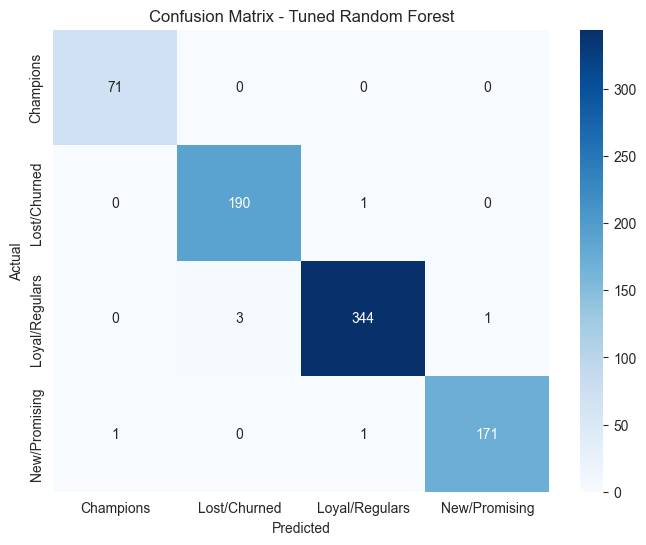

In [21]:
# Updated to use the best_rf_clf and best_rf_pred
cm = confusion_matrix(y_test, best_rf_pred, labels=best_rf_clf.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_rf_clf.classes_, yticklabels=best_rf_clf.classes_)
plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Feature Importance

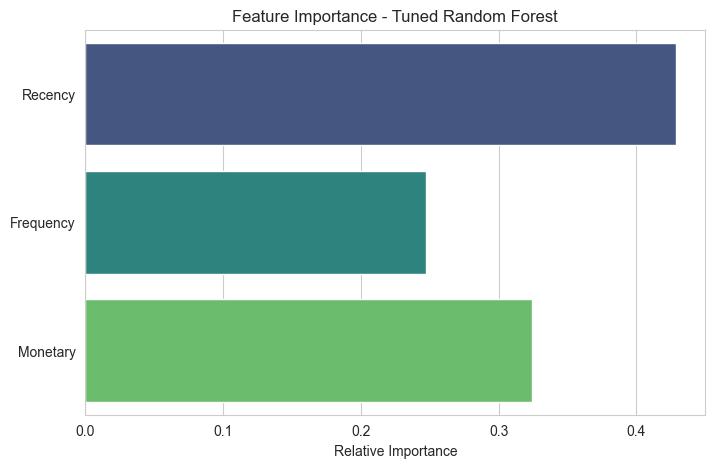

In [22]:
# Updated to extract importance from the tuned model
importances = best_rf_clf.feature_importances_
feature_names = ['Recency', 'Frequency', 'Monetary']

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title('Feature Importance - Tuned Random Forest')
plt.xlabel('Relative Importance')
plt.show()

#### ROC-AUC Curve
Visualizing the trade-off between the true positive rate and false positive rate for each of our customer personas (Multiclass One-vs-Rest approach).

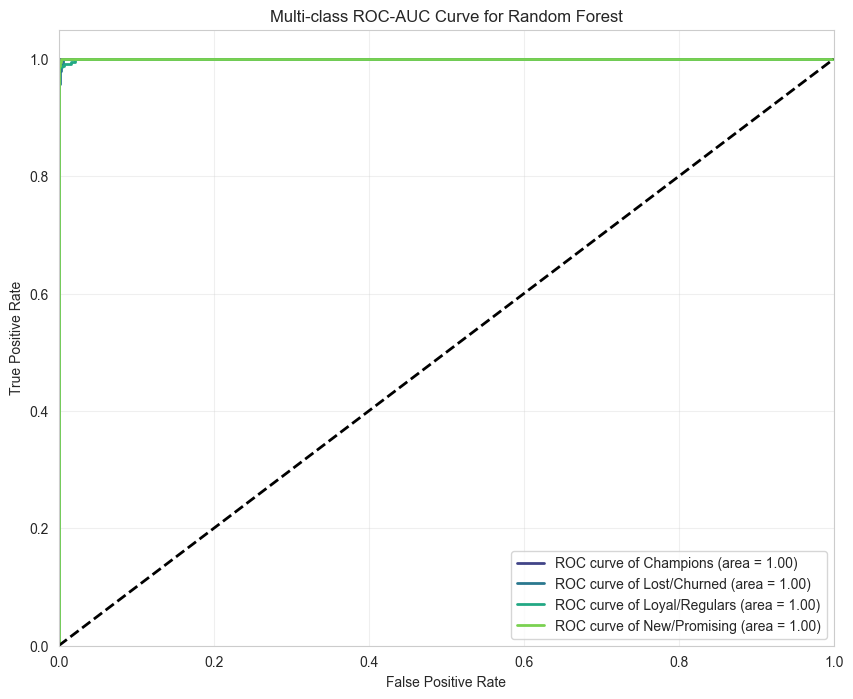

In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the output for multi-class ROC calculation
classes = best_rf_clf.classes_
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Predict probabilities
y_score = best_rf_clf.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = sns.color_palette('viridis', n_colors=n_classes)

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {classes[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC-AUC Curve for Random Forest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#### Business Insights
Based on the exploratory data analysis and K-Means segmentation, we identified four distinct customer personas:
1. **Champions:** High frequency, high monetary value, and recent purchases. These are the most valuable customers driving the majority of revenue.
2. **Loyal/Regulars:** Consistent purchasers with moderate spend. They shop regularly but haven't reached the spending tier of Champions.
3. **New/Promising:** Recent buyers but with low frequency and spend. They represent untapped potential.
4. **Lost/Churned:** High recency (haven't purchased in a long time), with low frequency and spend. These customers have likely churned.

*Note: The Random Forest model confirmed that **Recency** is the most critical feature in predicting a customer's segment, followed by Monetary value and Frequency.*

#### Limitations
1. **Distance Sensitivity:** K-Means clustering is highly sensitive to outliers. While we mitigated this using the IQR method, extreme high-value buyers had to be capped, potentially missing out on a "Whale" micro-segment.
2. **Temporal Scope:** The dataset only covers a specific timeframe. RFM metrics are snapshots; they do not account for seasonality or long-term lifecycle changes.
3. **Missing Data:** Over 135,000 rows were dropped due to missing `CustomerID`s. This means a significant portion of guest-checkout or untracked revenue is excluded from this model.

#### Final Recommendation
To optimize marketing strategies and improve retention, the following actions are recommended per segment:

* **Champions:** Do not over-discount. Focus on VIP treatment, early access to new products, and referral programs to leverage their brand loyalty.
* **Loyal/Regulars:** Implement upselling and cross-selling campaigns. Offer bundle discounts to increase their average order value (Monetary metric).
* **New/Promising:** Trigger automated onboarding email sequences. Provide a time-sensitive welcome discount to encourage their crucial second purchase (improving Frequency).
* **Lost/Churned:** Launch targeted win-back campaigns using aggressive discounts or "We miss you" messaging. If they do not engage after a set period, remove them from active mailing lists to save marketing costs.

In [24]:
# Save the tuned model instead of the baseline
joblib.dump(best_rf_clf, 'tuned_rf_customer_segmentation_model.pkl')
print("Model saved successfully as 'tuned_rf_customer_segmentation_model.pkl'")

Model saved successfully as 'tuned_rf_customer_segmentation_model.pkl'


In [25]:
# Export the segmented customer data for Power BI 
rfm_filtered.to_csv('customer_segments.csv', index=False)
print("Data successfully exported to 'customer_segments.csv'")

Data successfully exported to 'customer_segments.csv'
